In [1]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/nikhil1e9/loan-default/Loan_default.csv


In [4]:
import os

print("Files available in Kaggle input:\n")

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

Files available in Kaggle input:

/kaggle/input/datasets/nikhil1e9/loan-default/Loan_default.csv


In [5]:
import glob

csv_files = glob.glob(
    "/kaggle/input/**/*.csv",
    recursive=True
)

print("CSV files found:")

for file in csv_files:
    print(file)

CSV files found:
/kaggle/input/datasets/nikhil1e9/loan-default/Loan_default.csv


In [6]:
import glob
import pandas as pd

csv_files = glob.glob(
    "/kaggle/input/**/*.csv",
    recursive=True
)

# Find the Loan_default.csv file
loan_files = [
    file for file in csv_files
    if "Loan_default.csv" in file
]

print("Matching files:", loan_files)

Matching files: ['/kaggle/input/datasets/nikhil1e9/loan-default/Loan_default.csv']


In [7]:
file_path = loan_files[0]

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (255347, 18)


In [8]:
print("Column names:")
print(df.columns.tolist())

Column names:
['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [9]:
display(df.head())

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [11]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


In [12]:
print("Default distribution:")
print(df["Default"].value_counts())

print("\nDefault percentage:")
print(df["Default"].value_counts(normalize=True) * 100)

Default distribution:
Default
0    225694
1     29653
Name: count, dtype: int64

Default percentage:
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


In [13]:
print("Total rows:", len(df))
print("Unique Loan IDs:", df["LoanID"].nunique())
print("Duplicate Loan IDs:", df["LoanID"].duplicated().sum())

Total rows: 255347
Unique Loan IDs: 255347
Duplicate Loan IDs: 0


In [14]:
categorical_columns = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
]

for col in categorical_columns:
    print("\n" + "=" * 50)
    print(col)
    print(df[col].value_counts())


Education
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

EmploymentType
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

HasMortgage
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64

HasDependents
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64

LoanPurpose
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

HasCoSigner
HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64


In [15]:
numeric_columns = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio"
]

display(df[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9


In [16]:
checks = {
    "Age <= 0": (df["Age"] <= 0).sum(),
    "Income < 0": (df["Income"] < 0).sum(),
    "LoanAmount <= 0": (df["LoanAmount"] <= 0).sum(),
    "CreditScore < 0": (df["CreditScore"] < 0).sum(),
    "CreditScore > 850": (df["CreditScore"] > 850).sum(),
    "InterestRate < 0": (df["InterestRate"] < 0).sum(),
    "LoanTerm <= 0": (df["LoanTerm"] <= 0).sum(),
    "DTIRatio < 0": (df["DTIRatio"] < 0).sum()
}

for check, count in checks.items():
    print(f"{check}: {count}")

Age <= 0: 0
Income < 0: 0
LoanAmount <= 0: 0
CreditScore < 0: 0
CreditScore > 850: 0
InterestRate < 0: 0
LoanTerm <= 0: 0
DTIRatio < 0: 0


In [17]:
# Create a working copy
data = df.copy()

print("Original shape:", df.shape)
print("Working dataset shape:", data.shape)

Original shape: (255347, 18)
Working dataset shape: (255347, 18)


In [18]:
data = data.drop(columns=["LoanID"])

print("Shape after removing LoanID:", data.shape)
print(data.columns.tolist())

Shape after removing LoanID: (255347, 17)
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [19]:
X = data.drop(columns=["Default"])
y = data["Default"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (255347, 16)
y shape: (255347,)


In [20]:
numeric_columns = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio"
]

correlation = data[numeric_columns + ["Default"]].corr()

display(correlation["Default"].sort_values(ascending=False))

Default           1.000000
InterestRate      0.131273
LoanAmount        0.086659
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
CreditScore      -0.034166
MonthsEmployed   -0.097374
Income           -0.099119
Age              -0.167783
Name: Default, dtype: float64

In [21]:
for column in numeric_columns:
    print("\n" + "=" * 50)
    print(column)
    print(data.groupby("Default")[column].mean())


Age
Default
0    44.409962
1    36.559539
Name: Age, dtype: float64

Income
Default
0    83899.165995
1    71844.722659
Name: Income, dtype: float64

LoanAmount
Default
0    125353.656017
1    144515.311469
Name: LoanAmount, dtype: float64

CreditScore
Default
0    576.232270
1    559.286143
Name: CreditScore, dtype: float64

MonthsEmployed
Default
0    60.764721
1    50.235457
Name: MonthsEmployed, dtype: float64

NumCreditLines
Default
0    2.489566
1    2.588338
Name: NumCreditLines, dtype: float64

InterestRate
Default
0    13.176994
1    15.896227
Name: InterestRate, dtype: float64

LoanTerm
Default
0    36.022544
1    36.051394
Name: LoanTerm, dtype: float64

DTIRatio
Default
0    0.498602
1    0.512467
Name: DTIRatio, dtype: float64


In [23]:
print(
    data.groupby("EmploymentType")["Default"]
    .mean()
    .sort_values(ascending=False)
)

EmploymentType
Unemployed       0.135529
Part-time        0.119652
Self-employed    0.114620
Full-time        0.094634
Name: Default, dtype: float64


In [24]:
print(
    data.groupby("LoanPurpose")["Default"]
    .mean()
    .sort_values(ascending=False)
)

LoanPurpose
Business     0.123260
Auto         0.118814
Education    0.118381
Other        0.117885
Home         0.102348
Name: Default, dtype: float64


In [194]:
data["CreditScoreGroup"] = pd.cut(
    data["CreditScore"],
    bins=[299, 450, 550, 650, 750, 850],
    labels=[
        "300-450",
        "451-550",
        "551-650",
        "651-750",
        "751-850"
    ]
)

In [141]:
credit_default_rate = (
    data.groupby("CreditScoreGroup", observed=True)["Default"]
    .mean()
)

print(credit_default_rate)

CreditScoreGroup
300-450    0.129927
451-550    0.119640
551-650    0.115022
651-750    0.108108
751-850    0.100687
Name: Default, dtype: float64


In [176]:
data = data.drop(columns=["CreditScoreGroup"])

KeyError: "['CreditScoreGroup'] not found in axis"

In [195]:
# Remove the temporary analysis column if it exists
data = data.drop(columns=["CreditScoreGroup"], errors="ignore")

print("Temporary column removed successfully.")
print("Current shape:", data.shape)

Temporary column removed successfully.
Current shape: (255347, 17)


In [196]:
print(data.columns.tolist())

['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


In [197]:
data.to_csv(
    "/kaggle/working/clean_loan_default.csv",
    index=False
)

print("Clean dataset saved successfully!")
print(data.shape)

Clean dataset saved successfully!
(255347, 17)


In [198]:
# Separate features and target

X = data.drop(columns=["Default"])
y = data["Default"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (255347, 16)
Target shape: (255347,)


In [199]:
print("Numerical columns:")
print(X.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical columns:")
print(X.select_dtypes(include=["object"]).columns.tolist())

Numerical columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']

Categorical columns:
['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [200]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (204277, 16)
y_train: (204277,)

Testing data:
X_test: (51070, 16)
y_test: (51070,)


In [201]:
print("Training default distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting default distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training default distribution:
Default
0    88.387337
1    11.612663
Name: proportion, dtype: float64

Testing default distribution:
Default
0    88.386528
1    11.613472
Name: proportion, dtype: float64


In [202]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio"
]

categorical_features = [
    "Education",
    "EmploymentType",
    "MaritalStatus",
    "HasMortgage",
    "HasDependents",
    "LoanPurpose",
    "HasCoSigner"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [203]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("Original X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (204277, 16)
Processed X_train shape: (204277, 31)
Original X_test shape: (51070, 16)
Processed X_test shape: (51070, 31)


In [204]:
from sklearn.linear_model import LogisticRegression

print("Logistic Regression imported successfully!")

Logistic Regression imported successfully!


In [205]:
logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [206]:
y_pred = logistic_model.predict(X_test_processed)

y_prob = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

print("Predictions generated successfully!")

print("First 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 default probabilities:")
print(y_prob[:10])

Predictions generated successfully!
First 10 predicted classes:
[0 0 0 1 0 0 1 0 1 1]

First 10 default probabilities:
[0.18627492 0.14007525 0.37846532 0.56939816 0.40783312 0.06909883
 0.80508595 0.36769876 0.79597628 0.59368737]


In [207]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("LOGISTIC REGRESSION RESULTS")
print("=" * 40)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

LOGISTIC REGRESSION RESULTS
Accuracy  : 0.6764
Precision : 0.2195
Recall    : 0.6990
F1 Score  : 0.3341
ROC-AUC   : 0.7532
PR-AUC    : 0.3105


Confusion Matrix:
[[30397 14742]
 [ 1785  4146]]


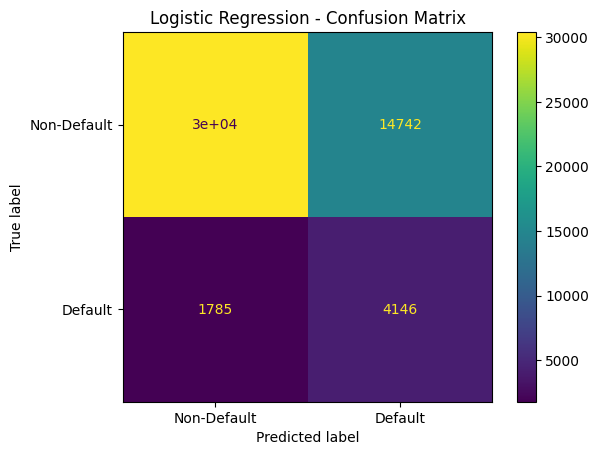

In [208]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Default", "Default"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [209]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Default", "Default"]
    )
)

              precision    recall  f1-score   support

 Non-Default       0.94      0.67      0.79     45139
     Default       0.22      0.70      0.33      5931

    accuracy                           0.68     51070
   macro avg       0.58      0.69      0.56     51070
weighted avg       0.86      0.68      0.73     51070



In [210]:
import joblib

joblib.dump(
    logistic_model,
    "/kaggle/working/logistic_baseline.pkl"
)

joblib.dump(
    preprocessor,
    "/kaggle/working/preprocessor.pkl"
)

print("Baseline model saved successfully!")

Baseline model saved successfully!


In [212]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [213]:
# Random Forest predictions

rf_pred = random_forest_model.predict(X_test_processed)

rf_prob = random_forest_model.predict_proba(
    X_test_processed
)[:, 1]

print("Random Forest predictions generated successfully!")

print("\nFirst 10 predicted classes:")
print(rf_pred[:10])

print("\nFirst 10 default probabilities:")
print(rf_prob[:10])

Random Forest predictions generated successfully!

First 10 predicted classes:
[0 0 0 0 0 0 1 0 1 1]

First 10 default probabilities:
[0.20454677 0.17672442 0.31394003 0.42544319 0.33026341 0.14009857
 0.69377261 0.31232071 0.62761911 0.50850012]


In [214]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

rf_roc_auc = roc_auc_score(y_test, rf_prob)
rf_pr_auc = average_precision_score(y_test, rf_prob)

print("RANDOM FOREST RESULTS")
print("=" * 40)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")
print(f"PR-AUC    : {rf_pr_auc:.4f}")

RANDOM FOREST RESULTS
Accuracy  : 0.7753
Precision : 0.2716
Recall    : 0.5554
F1 Score  : 0.3648
ROC-AUC   : 0.7554
PR-AUC    : 0.3183


In [215]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

print("RANDOM FOREST THRESHOLD ANALYSIS")
print("=" * 65)

for threshold in thresholds:

    threshold_pred = (rf_prob >= threshold).astype(int)

    precision = precision_score(y_test, threshold_pred)
    recall = recall_score(y_test, threshold_pred)
    f1 = f1_score(y_test, threshold_pred)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

RANDOM FOREST THRESHOLD ANALYSIS
Threshold: 0.30 | Precision: 0.1581 | Recall: 0.9010 | F1: 0.2689
Threshold: 0.35 | Precision: 0.1805 | Recall: 0.8393 | F1: 0.2971
Threshold: 0.40 | Precision: 0.2053 | Recall: 0.7545 | F1: 0.3228
Threshold: 0.45 | Precision: 0.2359 | Recall: 0.6628 | F1: 0.3480
Threshold: 0.50 | Precision: 0.2716 | Recall: 0.5554 | F1: 0.3648


In [216]:
# Selected operating threshold
selected_threshold = 0.45

rf_threshold_pred = (
    rf_prob >= selected_threshold
).astype(int)

print("RANDOM FOREST - THRESHOLD 0.45")
print("=" * 45)

print("Accuracy  :", accuracy_score(y_test, rf_threshold_pred))
print("Precision :", precision_score(y_test, rf_threshold_pred))
print("Recall    :", recall_score(y_test, rf_threshold_pred))
print("F1 Score  :", f1_score(y_test, rf_threshold_pred))

print("\nConfusion Matrix:")

cm_rf_threshold = confusion_matrix(
    y_test,
    rf_threshold_pred
)

print(cm_rf_threshold)

RANDOM FOREST - THRESHOLD 0.45
Accuracy  : 0.711552770706873
Precision : 0.23592605929660304
Recall    : 0.6627887371438206
F1 Score  : 0.3479838888151197

Confusion Matrix:
[[32408 12731]
 [ 2000  3931]]


In [218]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get Random Forest feature importance
importances = random_forest_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display top 20
print("TOP 20 IMPORTANT FEATURES")
print("=" * 50)
print(feature_importance.head(20).to_string(index=False))

TOP 20 IMPORTANT FEATURES
                       Feature  Importance
                      num__Age    0.217925
             num__InterestRate    0.164096
                   num__Income    0.138017
           num__MonthsEmployed    0.101679
               num__LoanAmount    0.100679
              num__CreditScore    0.057871
                 num__DTIRatio    0.046398
                 num__LoanTerm    0.017438
           num__NumCreditLines    0.017437
 cat__EmploymentType_Full-time    0.009814
           cat__HasCoSigner_No    0.007644
cat__EmploymentType_Unemployed    0.007591
          cat__HasCoSigner_Yes    0.007478
         cat__HasDependents_No    0.007350
        cat__HasDependents_Yes    0.007197
    cat__MaritalStatus_Married    0.007162
    cat__Education_High School    0.006665
         cat__LoanPurpose_Home    0.006442
            cat__Education_PhD    0.006297
          cat__HasMortgage_Yes    0.006171


In [219]:
import joblib

# Save Random Forest model
joblib.dump(
    random_forest_model,
    "/kaggle/working/random_forest_baseline.pkl"
)

# Save the preprocessor used by the model
joblib.dump(
    preprocessor,
    "/kaggle/working/preprocessor_rf.pkl"
)

print("Random Forest baseline model saved successfully!")
print("Model: /kaggle/working/random_forest_baseline.pkl")
print("Preprocessor: /kaggle/working/preprocessor_rf.pkl")

Random Forest baseline model saved successfully!
Model: /kaggle/working/random_forest_baseline.pkl
Preprocessor: /kaggle/working/preprocessor_rf.pkl


In [220]:
import joblib

joblib.dump(
    random_forest_model,
    "/kaggle/working/random_forest_baseline.pkl"
)

joblib.dump(
    preprocessor,
    "/kaggle/working/preprocessor_rf.pkl"
)

print("Random Forest baseline model saved successfully!")

Random Forest baseline model saved successfully!


In [221]:
# STEP 1: Inspect the dataset

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape:
(255347, 18)

Column names:
['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']

Data types:
LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object

First 5 rows:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [222]:
# ============================================================
# STEP 2: ALTERNATIVE CREDIT PROXY FEATURES
# ============================================================

import numpy as np

# Work on a copy so the original dataset remains unchanged
df_alt = df.copy()

# ------------------------------------------------------------
# 1. Income-to-Loan Ratio
# Higher value = loan is smaller relative to income
# ------------------------------------------------------------
df_alt["IncomeLoanRatio"] = (
    df_alt["Income"] / (df_alt["LoanAmount"] + 1)
)

# ------------------------------------------------------------
# 2. Employment Stability
# Approximate employment stability from months employed
# ------------------------------------------------------------
df_alt["EmploymentStability"] = (
    df_alt["MonthsEmployed"] / 120
).clip(0, 1)

# ------------------------------------------------------------
# 3. Credit Utilization Proxy
# More credit lines can indicate greater credit dependence
# ------------------------------------------------------------
df_alt["CreditLineBurden"] = (
    df_alt["NumCreditLines"] /
    (df_alt["Income"] / 10000 + 1)
)

# ------------------------------------------------------------
# 4. Loan Burden
# Combines loan amount and income
# ------------------------------------------------------------
df_alt["LoanBurden"] = (
    df_alt["LoanAmount"] /
    (df_alt["Income"] + 1)
)

# ------------------------------------------------------------
# 5. Interest Burden
# Higher interest rate = potentially higher financial stress
# ------------------------------------------------------------
df_alt["InterestBurden"] = (
    df_alt["InterestRate"] *
    df_alt["LoanBurden"]
)

# ------------------------------------------------------------
# 6. Debt Stress Proxy
# Combines DTI and loan burden
# ------------------------------------------------------------
df_alt["DebtStress"] = (
    df_alt["DTIRatio"] +
    df_alt["LoanBurden"]
)

# ------------------------------------------------------------
# 7. Financial Stability Score
# Prototype score based on available financial variables
# ------------------------------------------------------------
credit_norm = (
    (df_alt["CreditScore"] - df_alt["CreditScore"].min()) /
    (df_alt["CreditScore"].max() - df_alt["CreditScore"].min())
)

employment_norm = (
    (df_alt["MonthsEmployed"] - df_alt["MonthsEmployed"].min()) /
    (df_alt["MonthsEmployed"].max() - df_alt["MonthsEmployed"].min())
)

income_norm = (
    (df_alt["Income"] - df_alt["Income"].min()) /
    (df_alt["Income"].max() - df_alt["Income"].min())
)

dti_norm = (
    (df_alt["DTIRatio"] - df_alt["DTIRatio"].min()) /
    (df_alt["DTIRatio"].max() - df_alt["DTIRatio"].min())
)

df_alt["FinancialStabilityScore"] = (
    0.40 * credit_norm +
    0.30 * employment_norm +
    0.20 * income_norm +
    0.10 * (1 - dti_norm)
)

# ------------------------------------------------------------
# 8. Repayment Capacity Proxy
# ------------------------------------------------------------
df_alt["RepaymentCapacity"] = (
    df_alt["Income"] /
    (df_alt["LoanAmount"] + 1)
) * (
    1 - df_alt["DTIRatio"].clip(0, 1)
)

print("Alternative-credit proxy features created successfully!")

print("\nNew features:")
new_features = [
    "IncomeLoanRatio",
    "EmploymentStability",
    "CreditLineBurden",
    "LoanBurden",
    "InterestBurden",
    "DebtStress",
    "FinancialStabilityScore",
    "RepaymentCapacity"
]

print(new_features)

print("\nSample values:")
display(
    df_alt[
        ["LoanID"] + new_features
    ].head(10)
)

Alternative-credit proxy features created successfully!

New features:
['IncomeLoanRatio', 'EmploymentStability', 'CreditLineBurden', 'LoanBurden', 'InterestBurden', 'DebtStress', 'FinancialStabilityScore', 'RepaymentCapacity']

Sample values:


,LoanID,IncomeLoanRatio,EmploymentStability,CreditLineBurden,LoanBurden,InterestBurden,DebtStress,FinancialStabilityScore,RepaymentCapacity
0,I38PQUQS96,1.699889,0.666667,0.416693,0.588255,8.959126,1.028255,0.524649,0.951938
1,HPSK72WA7R,0.405268,0.125000,0.165475,2.467432,11.868348,3.147432,0.232926,0.129686
2,C1OZ6DPJ8Y,0.651820,0.216667,0.318444,1.534135,32.477644,1.844135,0.351846,0.449756
3,V2KKSFM3UN,0.707879,0.000000,0.719200,1.412594,9.987038,1.642594,0.431279,0.545067
4,EY08JDHTZP,2.235996,0.066667,1.314190,0.447157,2.910994,1.177157,0.292096,0.603719
5,A9S62RQ7US,0.998331,0.150000,0.199406,1.001650,22.757490,1.101650,0.562942,0.898497
6,H8GXPAOS71,0.628089,0.666667,0.082516,1.592109,30.425202,1.752109,0.530672,0.527594
7,0HGZQKJ36W,0.815384,0.558333,0.292393,1.226398,9.995147,1.656398,0.561597,0.464769
8,1R0N3LGNRJ,0.455326,0.691667,0.192112,2.196153,52.575892,2.396153,0.720793,0.364261
9,CM9L1GTT2P,0.581084,0.950000,0.280143,1.720902,15.643001,2.050902,0.664289,0.389326


In [223]:
# ============================================================
# STEP 3: PREPARE DATA FOR ENHANCED RANDOM FOREST
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Target
y_alt = df_alt["Default"]

# Remove ID and target
X_alt = df_alt.drop(columns=["LoanID", "Default"])

# Identify numerical and categorical columns
numeric_features_alt = X_alt.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_alt = X_alt.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", len(numeric_features_alt))
print("Categorical features:", len(categorical_features_alt))

print("\nAlternative numerical features:")
print(numeric_features_alt)

print("\nCategorical features:")
print(categorical_features_alt)

# ------------------------------------------------------------
# Preprocessing
# ------------------------------------------------------------

numeric_transformer_alt = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer_alt = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor_alt = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_alt, numeric_features_alt),
        ("cat", categorical_transformer_alt, categorical_features_alt)
    ]
)

# ------------------------------------------------------------
# Train-test split
# ------------------------------------------------------------

X_alt_train, X_alt_test, y_alt_train, y_alt_test = train_test_split(
    X_alt,
    y_alt,
    test_size=0.20,
    random_state=42,
    stratify=y_alt
)

# ------------------------------------------------------------
# Transform data
# ------------------------------------------------------------

X_alt_train_processed = preprocessor_alt.fit_transform(X_alt_train)
X_alt_test_processed = preprocessor_alt.transform(X_alt_test)

print("\nEnhanced dataset prepared successfully!")

print("Training shape:", X_alt_train_processed.shape)
print("Testing shape:", X_alt_test_processed.shape)

Numerical features: 17
Categorical features: 7

Alternative numerical features:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'IncomeLoanRatio', 'EmploymentStability', 'CreditLineBurden', 'LoanBurden', 'InterestBurden', 'DebtStress', 'FinancialStabilityScore', 'RepaymentCapacity']

Categorical features:
['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

Enhanced dataset prepared successfully!
Training shape: (204277, 39)
Testing shape: (51070, 39)


In [224]:
# ============================================================
# STEP 4: TRAIN ENHANCED RANDOM FOREST
# ============================================================

from sklearn.ensemble import RandomForestClassifier

enhanced_rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

enhanced_rf_model.fit(
    X_alt_train_processed,
    y_alt_train
)

print("Enhanced Random Forest trained successfully!")

Enhanced Random Forest trained successfully!


In [225]:
# ============================================================
# STEP 5: ENHANCED RANDOM FOREST PREDICTIONS
# ============================================================

enhanced_rf_pred = enhanced_rf_model.predict(X_alt_test_processed)

enhanced_rf_prob = enhanced_rf_model.predict_proba(
    X_alt_test_processed
)[:, 1]

print("Enhanced Random Forest predictions generated successfully!")

print("\nFirst 10 predicted classes:")
print(enhanced_rf_pred[:10])

print("\nFirst 10 default probabilities:")
print(enhanced_rf_prob[:10])

Enhanced Random Forest predictions generated successfully!

First 10 predicted classes:
[0 0 0 0 0 0 1 0 1 1]

First 10 default probabilities:
[0.21108426 0.10454877 0.24701072 0.29044293 0.26562234 0.08558328
 0.6121184  0.20716951 0.55627112 0.50118225]


In [226]:
# ============================================================
# STEP 6: ENHANCED RANDOM FOREST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Calculate metrics
enhanced_accuracy = accuracy_score(
    y_alt_test,
    enhanced_rf_pred
)

enhanced_precision = precision_score(
    y_alt_test,
    enhanced_rf_pred
)

enhanced_recall = recall_score(
    y_alt_test,
    enhanced_rf_pred
)

enhanced_f1 = f1_score(
    y_alt_test,
    enhanced_rf_pred
)

enhanced_roc_auc = roc_auc_score(
    y_alt_test,
    enhanced_rf_prob
)

enhanced_pr_auc = average_precision_score(
    y_alt_test,
    enhanced_rf_prob
)

# Display results
print("ENHANCED RANDOM FOREST RESULTS")
print("=" * 45)

print(f"Accuracy  : {enhanced_accuracy:.4f}")
print(f"Precision : {enhanced_precision:.4f}")
print(f"Recall    : {enhanced_recall:.4f}")
print(f"F1 Score  : {enhanced_f1:.4f}")
print(f"ROC-AUC   : {enhanced_roc_auc:.4f}")
print(f"PR-AUC    : {enhanced_pr_auc:.4f}")

# Confusion Matrix
print("\nConfusion Matrix:")
cm_enhanced = confusion_matrix(
    y_alt_test,
    enhanced_rf_pred
)

print(cm_enhanced)

ENHANCED RANDOM FOREST RESULTS
Accuracy  : 0.8150
Precision : 0.3019
Recall    : 0.4517
F1 Score  : 0.3619
ROC-AUC   : 0.7514
PR-AUC    : 0.3182

Confusion Matrix:
[[38945  6194]
 [ 3252  2679]]


In [227]:
# ============================================================
# STEP 7: ENHANCED RANDOM FOREST THRESHOLD ANALYSIS
# ============================================================

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50]

print("ENHANCED RANDOM FOREST - THRESHOLD ANALYSIS")
print("=" * 70)

for threshold in thresholds:

    threshold_pred = (
        enhanced_rf_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_alt_test,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_alt_test,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_alt_test,
        threshold_pred,
        zero_division=0
    )

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

ENHANCED RANDOM FOREST - THRESHOLD ANALYSIS
Threshold: 0.30 | Precision: 0.1842 | Recall: 0.8211 | F1: 0.3010
Threshold: 0.35 | Precision: 0.2085 | Recall: 0.7355 | F1: 0.3249
Threshold: 0.40 | Precision: 0.2351 | Recall: 0.6447 | F1: 0.3446
Threshold: 0.45 | Precision: 0.2662 | Recall: 0.5439 | F1: 0.3574
Threshold: 0.50 | Precision: 0.3019 | Recall: 0.4517 | F1: 0.3619


In [228]:
# ============================================================
# STEP 8: FIND BEST THRESHOLD
# ============================================================

import numpy as np

threshold_range = np.arange(0.20, 0.71, 0.01)

best_threshold = 0
best_f1 = 0

threshold_results = []

for threshold in threshold_range:

    threshold_pred = (
        enhanced_rf_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_alt_test,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_alt_test,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_alt_test,
        threshold_pred,
        zero_division=0
    )

    threshold_results.append(
        [threshold, precision, recall, f1]
    )

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold


print("OPTIMAL THRESHOLD")
print("=" * 40)

print(f"Best Threshold : {best_threshold:.2f}")
print(f"Best F1 Score  : {best_f1:.4f}")

# Get metrics at best threshold
best_pred = (
    enhanced_rf_prob >= best_threshold
).astype(int)

best_precision = precision_score(
    y_alt_test,
    best_pred,
    zero_division=0
)

best_recall = recall_score(
    y_alt_test,
    best_pred,
    zero_division=0
)

print(f"Precision      : {best_precision:.4f}")
print(f"Recall         : {best_recall:.4f}")

OPTIMAL THRESHOLD
Best Threshold : 0.47
Best F1 Score  : 0.3628
Precision      : 0.2820
Recall         : 0.5085


In [229]:
# ============================================================
# STEP 9: FINAL RISK CLASSIFICATION
# ============================================================

FINAL_THRESHOLD = 0.47

# Final predictions using optimized threshold
final_pred = (
    enhanced_rf_prob >= FINAL_THRESHOLD
).astype(int)

print("FINAL RISK CLASSIFICATION")
print("=" * 45)

print(f"Risk Threshold : {FINAL_THRESHOLD}")
print(f"High-Risk cases: {final_pred.sum()}")
print(f"Low-Risk cases : {(final_pred == 0).sum()}")

print("\nClass distribution:")
print(pd.Series(final_pred).value_counts().sort_index())

FINAL RISK CLASSIFICATION
Risk Threshold : 0.47
High-Risk cases: 10695
Low-Risk cases : 40375

Class distribution:
0    40375
1    10695
Name: count, dtype: int64


In [230]:
# ============================================================
# STEP 10: SAVE ENHANCED MODEL
# ============================================================

import joblib

joblib.dump(
    enhanced_rf_model,
    "/kaggle/working/enhanced_random_forest.pkl"
)

joblib.dump(
    preprocessor_alt,
    "/kaggle/working/enhanced_preprocessor.pkl"
)

# Save the selected threshold separately
joblib.dump(
    FINAL_THRESHOLD,
    "/kaggle/working/risk_threshold.pkl"
)

print("Enhanced model saved successfully!")
print("Model       : enhanced_random_forest.pkl")
print("Preprocessor: enhanced_preprocessor.pkl")
print("Threshold   : risk_threshold.pkl")

Enhanced model saved successfully!
Model       : enhanced_random_forest.pkl
Preprocessor: enhanced_preprocessor.pkl
Threshold   : risk_threshold.pkl


In [231]:
# ============================================================
# STEP 11: SINGLE CUSTOMER RISK PREDICTION
# ============================================================

import pandas as pd
import numpy as np
import joblib

# ------------------------------------------------------------
# Load saved model, preprocessor and threshold
# ------------------------------------------------------------

enhanced_rf_model = joblib.load(
    "/kaggle/working/enhanced_random_forest.pkl"
)

preprocessor_alt = joblib.load(
    "/kaggle/working/enhanced_preprocessor.pkl"
)

FINAL_THRESHOLD = joblib.load(
    "/kaggle/working/risk_threshold.pkl"
)


# ------------------------------------------------------------
# Prediction function
# ------------------------------------------------------------

def predict_customer_risk(customer_data):

    # Convert input dictionary to DataFrame
    customer = pd.DataFrame([customer_data])

    # --------------------------------------------------------
    # Create the SAME alternative-credit features
    # used during model training
    # --------------------------------------------------------

    customer["IncomeLoanRatio"] = (
        customer["Income"] /
        (customer["LoanAmount"] + 1)
    )

    customer["EmploymentStability"] = (
        customer["MonthsEmployed"] / 120
    ).clip(0, 1)

    customer["CreditLineBurden"] = (
        customer["NumCreditLines"] /
        (customer["Income"] / 10000 + 1)
    )

    customer["LoanBurden"] = (
        customer["LoanAmount"] /
        (customer["Income"] + 1)
    )

    customer["InterestBurden"] = (
        customer["InterestRate"] *
        customer["LoanBurden"]
    )

    customer["DebtStress"] = (
        customer["DTIRatio"] +
        customer["LoanBurden"]
    )

    # --------------------------------------------------------
    # Financial Stability Score
    # Use training dataset min/max values
    # --------------------------------------------------------

    credit_min = df_alt["CreditScore"].min()
    credit_max = df_alt["CreditScore"].max()

    employment_min = df_alt["MonthsEmployed"].min()
    employment_max = df_alt["MonthsEmployed"].max()

    income_min = df_alt["Income"].min()
    income_max = df_alt["Income"].max()

    dti_min = df_alt["DTIRatio"].min()
    dti_max = df_alt["DTIRatio"].max()

    # Avoid division by zero
    credit_range = max(credit_max - credit_min, 1)
    employment_range = max(employment_max - employment_min, 1)
    income_range = max(income_max - income_min, 1)
    dti_range = max(dti_max - dti_min, 1)

    credit_norm = (
        (customer["CreditScore"] - credit_min) /
        credit_range
    )

    employment_norm = (
        (customer["MonthsEmployed"] - employment_min) /
        employment_range
    )

    income_norm = (
        (customer["Income"] - income_min) /
        income_range
    )

    dti_norm = (
        (customer["DTIRatio"] - dti_min) /
        dti_range
    )

    customer["FinancialStabilityScore"] = (
        0.40 * credit_norm +
        0.30 * employment_norm +
        0.20 * income_norm +
        0.10 * (1 - dti_norm)
    )

    # --------------------------------------------------------
    # Repayment Capacity
    # --------------------------------------------------------

    customer["RepaymentCapacity"] = (
        customer["Income"] /
        (customer["LoanAmount"] + 1)
    ) * (
        1 - customer["DTIRatio"].clip(0, 1)
    )

    # --------------------------------------------------------
    # Remove LoanID if it exists
    # --------------------------------------------------------

    if "LoanID" in customer.columns:
        customer_model = customer.drop(columns=["LoanID"])
    else:
        customer_model = customer.copy()

    # --------------------------------------------------------
    # Apply SAME preprocessing used during training
    # --------------------------------------------------------

    customer_processed = preprocessor_alt.transform(
        customer_model
    )

    # --------------------------------------------------------
    # Get probability of default
    # --------------------------------------------------------

    default_probability = enhanced_rf_model.predict_proba(
        customer_processed
    )[:, 1][0]

    # --------------------------------------------------------
    # Apply optimized threshold = 0.47
    # --------------------------------------------------------

    risk_prediction = int(
        default_probability >= FINAL_THRESHOLD
    )

    # --------------------------------------------------------
    # Risk classification
    # --------------------------------------------------------

    if risk_prediction == 1:
        risk_class = "HIGH RISK"
    else:
        risk_class = "LOW RISK"

    # --------------------------------------------------------
    # Return results
    # --------------------------------------------------------

    result = {
        "Default Probability": round(
            default_probability * 100, 2
        ),
        "Risk Threshold": FINAL_THRESHOLD,
        "Risk Class": risk_class,
        "Prediction": risk_prediction
    }

    return result


print("Single-customer prediction function created successfully!")

Single-customer prediction function created successfully!


In [232]:
# ============================================================
# TEST SINGLE CUSTOMER PREDICTION
# ============================================================

test_customer = {
    "Age": 35,
    "Income": 60000,
    "LoanAmount": 25000,
    "CreditScore": 700,
    "MonthsEmployed": 60,
    "NumCreditLines": 3,
    "InterestRate": 10.5,
    "LoanTerm": 36,
    "DTIRatio": 0.30,
    "Education": "Bachelor's",
    "EmploymentType": "Full-time",
    "MaritalStatus": "Married",
    "HasMortgage": "Yes",
    "HasDependents": "No",
    "LoanPurpose": "Home",
    "HasCoSigner": "No"
}

result = predict_customer_risk(test_customer)

print("\nCUSTOMER RISK ASSESSMENT")
print("=" * 40)
print(f"Default Probability : {result['Default Probability']}%")
print(f"Risk Threshold      : {result['Risk Threshold']}")
print(f"Risk Classification : {result['Risk Class']}")
print(f"Prediction          : {result['Prediction']}")


CUSTOMER RISK ASSESSMENT
Default Probability : 26.17%
Risk Threshold      : 0.47
Risk Classification : LOW RISK
Prediction          : 0


In [233]:
# ============================================================
# STEP 12: EXPLAINABLE RISK ASSESSMENT
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# Get feature names after preprocessing
# ------------------------------------------------------------

feature_names = preprocessor_alt.get_feature_names_out()

# Get Random Forest feature importance
importances = enhanced_rf_model.feature_importances_

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# Display top 15 features
# ------------------------------------------------------------

print("TOP 15 RISK-RELEVANT FEATURES")
print("=" * 50)

display(
    feature_importance.head(15)
)

# ------------------------------------------------------------
# Save feature importance
# ------------------------------------------------------------

feature_importance.to_csv(
    "/kaggle/working/feature_importance.csv",
    index=False
)

print("\nFeature importance saved successfully!")

TOP 15 RISK-RELEVANT FEATURES


,Feature,Importance
0,num__Age,0.154127
1,num__InterestBurden,0.098907
2,num__InterestRate,0.091976
3,num__DebtStress,0.057867
4,num__LoanBurden,0.051690
5,num__IncomeLoanRatio,0.051394
6,num__FinancialStabilityScore,0.050233
7,num__MonthsEmployed,0.048071
8,num__EmploymentStability,0.047812
9,num__RepaymentCapacity,0.044036



Feature importance saved successfully!


In [234]:
# ============================================================
# STEP 13: CUSTOMER-SPECIFIC RISK EXPLANATION
# ============================================================

import shap
import numpy as np
import pandas as pd

def explain_customer_risk(customer_data):

    # --------------------------------------------------------
    # Get the customer's prediction
    # --------------------------------------------------------
    result = predict_customer_risk(customer_data)

    # Create dataframe
    customer = pd.DataFrame([customer_data])

    # --------------------------------------------------------
    # Recreate alternative-credit features
    # --------------------------------------------------------

    customer["IncomeLoanRatio"] = (
        customer["Income"] /
        (customer["LoanAmount"] + 1)
    )

    customer["EmploymentStability"] = (
        customer["MonthsEmployed"] / 120
    ).clip(0, 1)

    customer["CreditLineBurden"] = (
        customer["NumCreditLines"] /
        (customer["Income"] / 10000 + 1)
    )

    customer["LoanBurden"] = (
        customer["LoanAmount"] /
        (customer["Income"] + 1)
    )

    customer["InterestBurden"] = (
        customer["InterestRate"] *
        customer["LoanBurden"]
    )

    customer["DebtStress"] = (
        customer["DTIRatio"] +
        customer["LoanBurden"]
    )

    # Same training-data normalization
    credit_range = max(
        df_alt["CreditScore"].max() -
        df_alt["CreditScore"].min(), 1
    )

    employment_range = max(
        df_alt["MonthsEmployed"].max() -
        df_alt["MonthsEmployed"].min(), 1
    )

    income_range = max(
        df_alt["Income"].max() -
        df_alt["Income"].min(), 1
    )

    dti_range = max(
        df_alt["DTIRatio"].max() -
        df_alt["DTIRatio"].min(), 1
    )

    credit_norm = (
        (customer["CreditScore"] -
         df_alt["CreditScore"].min()) /
        credit_range
    )

    employment_norm = (
        (customer["MonthsEmployed"] -
         df_alt["MonthsEmployed"].min()) /
        employment_range
    )

    income_norm = (
        (customer["Income"] -
         df_alt["Income"].min()) /
        income_range
    )

    dti_norm = (
        (customer["DTIRatio"] -
         df_alt["DTIRatio"].min()) /
        dti_range
    )

    customer["FinancialStabilityScore"] = (
        0.40 * credit_norm +
        0.30 * employment_norm +
        0.20 * income_norm +
        0.10 * (1 - dti_norm)
    )

    customer["RepaymentCapacity"] = (
        customer["Income"] /
        (customer["LoanAmount"] + 1)
    ) * (
        1 - customer["DTIRatio"].clip(0, 1)
    )

    # --------------------------------------------------------
    # Remove LoanID
    # --------------------------------------------------------

    if "LoanID" in customer.columns:
        customer_model = customer.drop(columns=["LoanID"])
    else:
        customer_model = customer.copy()

    # --------------------------------------------------------
    # Transform customer
    # --------------------------------------------------------

    customer_processed = preprocessor_alt.transform(
        customer_model
    )

    # --------------------------------------------------------
    # SHAP explanation
    # --------------------------------------------------------

    explainer = shap.TreeExplainer(enhanced_rf_model)

    shap_values = explainer.shap_values(
        customer_processed
    )

    # Handle SHAP output format
    if isinstance(shap_values, list):
        customer_shap = shap_values[1][0]
    else:
        shap_array = np.asarray(shap_values)

        if shap_array.ndim == 3:
            customer_shap = shap_array[0, :, 1]
        else:
            customer_shap = shap_array[0]

    # Feature names
    feature_names = preprocessor_alt.get_feature_names_out()

    explanation = pd.DataFrame({
        "Feature": feature_names,
        "Contribution": customer_shap
    })

    explanation["AbsoluteContribution"] = (
        explanation["Contribution"].abs()
    )

    explanation = explanation.sort_values(
        "AbsoluteContribution",
        ascending=False
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # Display result
    # --------------------------------------------------------

    print("\nCUSTOMER-SPECIFIC RISK EXPLANATION")
    print("=" * 55)

    print(
        f"Risk Classification : {result['Risk Class']}"
    )

    print(
        f"Default Probability : "
        f"{result['Default Probability']}%"
    )

    print(
        f"Risk Threshold      : "
        f"{result['Risk Threshold']}"
    )

    print("\nTop Factors Affecting This Customer")
    print("-" * 55)

    display(
        explanation[
            ["Feature", "Contribution"]
        ].head(10)
    )

    return explanation


# Run explanation for test customer
customer_explanation = explain_customer_risk(
    test_customer
)


CUSTOMER-SPECIFIC RISK EXPLANATION
Risk Classification : LOW RISK
Default Probability : 26.17%
Risk Threshold      : 0.47

Top Factors Affecting This Customer
-------------------------------------------------------


,Feature,Contribution
0,num__InterestBurden,-0.059117
1,num__InterestRate,-0.047239
2,num__Age,0.034997
3,num__DebtStress,-0.021336
4,num__RepaymentCapacity,-0.019188
5,cat__EmploymentType_Full-time,-0.017890
6,num__FinancialStabilityScore,-0.015878
7,num__Income,-0.014651
8,num__CreditScore,-0.012904
9,num__IncomeLoanRatio,-0.012841


In [235]:
# ============================================================
# STEP 14: FINAL CUSTOMER RISK REPORT
# ============================================================

print("\n" + "=" * 60)
print("FINAL ALTERNATIVE CREDIT RISK REPORT")
print("=" * 60)

# ------------------------------------------------------------
# Customer details
# ------------------------------------------------------------

customer_id = customer["LoanID"]

print(f"\nCustomer ID          : {customer_id}")

# ------------------------------------------------------------
# Risk information
# ------------------------------------------------------------

print(f"Default Probability  : {result['Default Probability']}%")
print(f"Risk Threshold       : {result['Risk Threshold']}")
print(f"Risk Classification  : {result['Risk Class']}")
print(f"Prediction           : {result['Prediction']}")

# ------------------------------------------------------------
# Decision recommendation
# ------------------------------------------------------------

if result["Default Probability"] < 30:
    recommendation = "ELIGIBLE"
    explanation = "Low predicted default risk."
    
elif result["Default Probability"] < 50:
    recommendation = "MANUAL REVIEW"
    explanation = "Moderate predicted risk. Additional verification recommended."
    
else:
    recommendation = "HIGH RISK"
    explanation = "High predicted default risk. Additional safeguards required."

print(f"\nCredit Decision      : {recommendation}")
print(f"Reason               : {explanation}")

# ------------------------------------------------------------
# Alternative-credit indicators
# ------------------------------------------------------------

print("\nALTERNATIVE CREDIT INDICATORS")
print("-" * 60)

print(
    f"Financial Stability : "
    f"{customer['FinancialStabilityScore']:.4f}"
)

print(
    f"Repayment Capacity  : "
    f"{customer['RepaymentCapacity']:.4f}"
)

print(
    f"Employment Stability: "
    f"{customer['EmploymentStability']:.4f}"
)

print(
    f"Debt Stress         : "
    f"{customer['DebtStress']:.4f}"
)

print(
    f"Loan Burden         : "
    f"{customer['LoanBurden']:.4f}"
)

print(
    f"Interest Burden     : "
    f"{customer['InterestBurden']:.4f}"
)

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\nFINAL SUMMARY")
print("-" * 60)

print(
    f"Customer {customer_id} is classified as "
    f"{result['Risk Class']} with a "
    f"{result['Default Probability']}% predicted probability "
    f"of default."
)

print(
    f"Recommended Decision: {recommendation}"
)

print("\nFinal customer risk report generated successfully!")


FINAL ALTERNATIVE CREDIT RISK REPORT


NameError: name 'customer' is not defined

In [236]:
# ============================================================
# STEP 14: FINAL CUSTOMER RISK REPORT
# ============================================================

print("\n" + "=" * 60)
print("FINAL ALTERNATIVE CREDIT RISK REPORT")
print("=" * 60)

# Use the customer data already available in df_alt
customer_row = df_alt.iloc[0]

# Customer information
print(f"\nCustomer ID          : {customer_row['LoanID']}")

# Existing prediction result
print(f"Default Probability  : {result['Default Probability']}%")
print(f"Risk Threshold       : {result['Risk Threshold']}")
print(f"Risk Classification  : {result['Risk Class']}")
print(f"Prediction           : {result['Prediction']}")

# ------------------------------------------------------------
# Alternative credit indicators
# ------------------------------------------------------------

print("\nALTERNATIVE CREDIT INDICATORS")
print("-" * 60)

print(
    f"Financial Stability  : "
    f"{customer_row['FinancialStabilityScore']:.4f}"
)

print(
    f"Repayment Capacity   : "
    f"{customer_row['RepaymentCapacity']:.4f}"
)

print(
    f"Employment Stability : "
    f"{customer_row['EmploymentStability']:.4f}"
)

print(
    f"Debt Stress          : "
    f"{customer_row['DebtStress']:.4f}"
)

print(
    f"Loan Burden          : "
    f"{customer_row['LoanBurden']:.4f}"
)

print(
    f"Interest Burden      : "
    f"{customer_row['InterestBurden']:.4f}"
)

# ------------------------------------------------------------
# Credit decision
# ------------------------------------------------------------

probability = result["Default Probability"]

if probability < 30:
    recommendation = "ELIGIBLE"
elif probability < 50:
    recommendation = "MANUAL REVIEW"
else:
    recommendation = "HIGH RISK"

print("\nCREDIT DECISION")
print("-" * 60)
print(f"Recommended Decision : {recommendation}")

print("\nFinal customer risk report generated successfully!")


FINAL ALTERNATIVE CREDIT RISK REPORT

Customer ID          : I38PQUQS96
Default Probability  : 26.17%
Risk Threshold       : 0.47
Risk Classification  : LOW RISK
Prediction           : 0

ALTERNATIVE CREDIT INDICATORS
------------------------------------------------------------
Financial Stability  : 0.5246
Repayment Capacity   : 0.9519
Employment Stability : 0.6667
Debt Stress          : 1.0283
Loan Burden          : 0.5883
Interest Burden      : 8.9591

CREDIT DECISION
------------------------------------------------------------
Recommended Decision : ELIGIBLE

Final customer risk report generated successfully!


In [241]:
# ============================================================
# STEP 15: CUSTOMER INPUT -> AUTOMATIC RISK ASSESSMENT
# ============================================================

import pandas as pd
import numpy as np

print("=" * 60)
print("CUSTOMER INPUT - ALTERNATIVE CREDIT RISK ASSESSMENT")
print("=" * 60)

# ------------------------------------------------------------
# 1. CUSTOMER INPUT
# ------------------------------------------------------------

customer_input = {
    "Age": 30,
    "Income": 50000,
    "LoanAmount": 40000,
    "CreditScore": 650,
    "MonthsEmployed": 36,
    "NumCreditLines": 3,
    "InterestRate": 10.0,
    "LoanTerm": 36,
    "DTIRatio": 0.30,
    "Education": "Bachelor's",
    "EmploymentType": "Full-time",
    "MaritalStatus": "Single",
    "HasMortgage": "No",
    "HasDependents": "No",
    "LoanPurpose": "Home",
    "HasCoSigner": "No"
}

customer_df = pd.DataFrame([customer_input])

print("\nCustomer information:")
display(customer_df)

CUSTOMER INPUT - ALTERNATIVE CREDIT RISK ASSESSMENT

Customer information:


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,30,50000,40000,650,36,3,10.0,36,0.3,Bachelor's,Full-time,Single,No,No,Home,No


In [242]:
# ============================================================
# STEP 15.1: CREATE ALTERNATIVE CREDIT FEATURES
# ============================================================

customer_alt = customer_df.copy()

customer_alt["IncomeLoanRatio"] = (
    customer_alt["Income"] /
    (customer_alt["LoanAmount"] + 1)
)

customer_alt["EmploymentStability"] = (
    customer_alt["MonthsEmployed"] / 120
).clip(0, 1)

customer_alt["CreditLineBurden"] = (
    customer_alt["NumCreditLines"] /
    (customer_alt["Income"] / 10000 + 1)
)

customer_alt["LoanBurden"] = (
    customer_alt["LoanAmount"] /
    (customer_alt["Income"] + 1)
)

customer_alt["InterestBurden"] = (
    customer_alt["InterestRate"] *
    customer_alt["LoanBurden"]
)

customer_alt["DebtStress"] = (
    customer_alt["DTIRatio"] +
    customer_alt["LoanBurden"]
)

# Financial Stability Score
credit_norm = (
    (customer_alt["CreditScore"] - df_alt["CreditScore"].min()) /
    (df_alt["CreditScore"].max() - df_alt["CreditScore"].min())
).clip(0, 1)

employment_norm = (
    (customer_alt["MonthsEmployed"] - df_alt["MonthsEmployed"].min()) /
    (df_alt["MonthsEmployed"].max() - df_alt["MonthsEmployed"].min())
).clip(0, 1)

income_norm = (
    (customer_alt["Income"] - df_alt["Income"].min()) /
    (df_alt["Income"].max() - df_alt["Income"].min())
).clip(0, 1)

dti_norm = (
    (customer_alt["DTIRatio"] - df_alt["DTIRatio"].min()) /
    (df_alt["DTIRatio"].max() - df_alt["DTIRatio"].min())
).clip(0, 1)

customer_alt["FinancialStabilityScore"] = (
    0.40 * credit_norm +
    0.30 * employment_norm +
    0.20 * income_norm +
    0.10 * (1 - dti_norm)
)

customer_alt["RepaymentCapacity"] = (
    customer_alt["Income"] /
    (customer_alt["LoanAmount"] + 1)
) * (
    1 - customer_alt["DTIRatio"].clip(0, 1)
)

print("Alternative credit features generated successfully!")

display(
    customer_alt[
        [
            "IncomeLoanRatio",
            "EmploymentStability",
            "CreditLineBurden",
            "LoanBurden",
            "InterestBurden",
            "DebtStress",
            "FinancialStabilityScore",
            "RepaymentCapacity"
        ]
    ]
)


Alternative credit features generated successfully!


,IncomeLoanRatio,EmploymentStability,CreditLineBurden,LoanBurden,InterestBurden,DebtStress,FinancialStabilityScore,RepaymentCapacity
0,1.249969,0.3,0.5,0.799984,7.99984,1.099984,0.472618,0.874978


In [243]:
# ============================================================
# STEP 15.2: PREPROCESS CUSTOMER DATA
# ============================================================

X_customer = customer_alt[
    X_alt_train.columns
]

X_customer_processed = preprocessor_alt.transform(X_customer)

print("Customer data processed successfully!")
print("Processed shape:", X_customer_processed.shape)

Customer data processed successfully!
Processed shape: (1, 39)


In [244]:
# ============================================================
# STEP 15.3: PREDICT CUSTOMER RISK
# ============================================================

# Get default probability
customer_probability = enhanced_rf_model.predict_proba(
    X_customer_processed
)[:, 1][0]

# Apply optimized threshold
customer_prediction = int(
    customer_probability >= FINAL_THRESHOLD
)

# Risk classification
if customer_prediction == 1:
    risk_class = "HIGH RISK"
else:
    risk_class = "LOW RISK"

print("\n" + "=" * 60)
print("CUSTOMER RISK ASSESSMENT")
print("=" * 60)

print(f"Default Probability : {customer_probability * 100:.2f}%")
print(f"Risk Threshold      : {FINAL_THRESHOLD}")
print(f"Risk Classification : {risk_class}")
print(f"Prediction          : {customer_prediction}")


CUSTOMER RISK ASSESSMENT
Default Probability : 39.28%
Risk Threshold      : 0.47
Risk Classification : LOW RISK
Prediction          : 0


In [245]:
# ============================================================
# STEP 15.4: FINAL CREDIT DECISION
# ============================================================

if customer_probability < 0.30:
    decision = "ELIGIBLE"
elif customer_probability < FINAL_THRESHOLD:
    decision = "MANUAL REVIEW"
else:
    decision = "HIGH RISK - FURTHER REVIEW"

print("\n" + "=" * 60)
print("FINAL CREDIT DECISION")
print("=" * 60)

print(f"Default Probability : {customer_probability * 100:.2f}%")
print(f"Risk Threshold      : {FINAL_THRESHOLD}")
print(f"Risk Classification : {risk_class}")
print(f"Recommended Action  : {decision}")

print("\nALTERNATIVE CREDIT INDICATORS")
print("-" * 60)

print(
    f"Financial Stability : "
    f"{customer_alt['FinancialStabilityScore'].iloc[0]:.4f}"
)

print(
    f"Repayment Capacity  : "
    f"{customer_alt['RepaymentCapacity'].iloc[0]:.4f}"
)

print(
    f"Employment Stability: "
    f"{customer_alt['EmploymentStability'].iloc[0]:.4f}"
)

print(
    f"Debt Stress         : "
    f"{customer_alt['DebtStress'].iloc[0]:.4f}"
)

print(
    f"Loan Burden         : "
    f"{customer_alt['LoanBurden'].iloc[0]:.4f}"
)

print(
    f"Interest Burden     : "
    f"{customer_alt['InterestBurden'].iloc[0]:.4f}"
)

print("\nCustomer assessment completed successfully!")


FINAL CREDIT DECISION
Default Probability : 39.28%
Risk Threshold      : 0.47
Risk Classification : LOW RISK
Recommended Action  : MANUAL REVIEW

ALTERNATIVE CREDIT INDICATORS
------------------------------------------------------------
Financial Stability : 0.4726
Repayment Capacity  : 0.8750
Employment Stability: 0.3000
Debt Stress         : 1.1000
Loan Burden         : 0.8000
Interest Burden     : 7.9998

Customer assessment completed successfully!
